# Atividade 1 - Primeiro contato com PyTorch — Cat vs. Not Cat

## Objetivo
Construir uma rede neural simples para classificar imagens como gato ou não-gato.

O código não está pronto. Em cada etapa, você deverá desenvolver sua solução.

**Fluxo:** dados → rede neural → treinamento → resultado → uma alteração → comparação

### Dataset

O dataset desta atividade é o arquivo **`cat_not_cat.csv`**. Esse arquivo não possui cabeçalho. Cada linha representa uma imagem. As primeiras colunas contêm os valores dos pixels, e a última coluna contém o label da imagem.

O arquivo deve ficar na mesma pasta do notebook; caso contrário, ajuste o caminho no código.

> O objetivo desta atividade também é desenvolver sua autonomia na busca por conhecimento. Se você não souber como fazer algo, seja utilizar o GitHub, implementar uma etapa ou entender um conceito, pesquise e busque compreender antes de seguir. Faz parte da atividade aprender a encontrar as respostas.

> Você não precisa entender ainda toda a matemática do treinamento. Neste momento, o objetivo é aprender a usar o PyTorch e reconhecer as principais etapas.

## 0. Prepare sua branch no repositório

Antes de iniciar a atividade, acesse o repositório do projeto e crie uma branch própria para desenvolver e salvar seu exercício.

Repositório: https://github.com/LCCMat-UnB/segmentacao-laminas

Cada aluno deverá trabalhar em uma branch separada, sem alterar diretamente a branch main.

Use um nome que identifique claramente sua branch, por exemplo:

`atividade-1-seunome`

Não adicione o arquivo `cat_not_cat.csv` à sua branch. Faça o commit apenas do notebook e dos arquivos produzidos pela atividade.

Durante o desenvolvimento da atividade:

1. salve o notebook da atividade na sua branch;
2. faça commits ao longo do trabalho;
3. mantenha suas alterações apenas na sua branch;
4. ao finalizar a atividade, faça o último commit com a versão completa do notebook.

## 1. Conheça o dataset
Nesta etapa, você vai entender os dados antes de treinar o modelo.

Use as células de código abaixo para:
1. carregar o arquivo `cat_not_cat.csv`;
2. observar o formato de `X` e `y`;
3. visualizar algumas imagens.

### Responda
1. Quantos exemplos existem no dataset?
2. O que representa `X`?
3. O que representa `y`?
4. Quais são as duas classes?
5. Como uma imagem está representada nos dados?

In [28]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = Path("cat_not_cat.csv")

# Carrega o CSV (sem cabeçalho)
df = pd.read_csv(csv_path, header=None)

# Separa os dados em entrada (X) e saída (y)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].astype(int).values

# Use essas saídas para responder as perguntas da atividade
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("Valores únicos em y:", np.unique(y))
print("Primeiros 10 valores de X[0]:", X[0, :10]) 

Formato de X: (258, 12288)
Formato de y: (258,)
Valores únicos em y: [0 1]
Primeiros 10 valores de X[0]: [17. 31. 56. 22. 33. 59. 25. 35. 62. 25.]


Label da imagem 0: 0
Primeiros 10 pixels da imagem 0: [17. 31. 56. 22. 33. 59. 25. 35. 62. 25.]


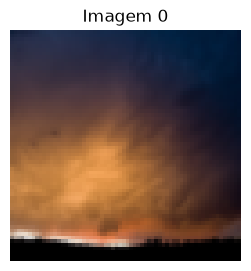

In [29]:
# Exemplo: olhando a primeira linha do CSV
print("Label da imagem 0:", y[0])
print("Primeiros 10 pixels da imagem 0:", X[0, :10])

# Para visualizar, reorganizamos os 12288 pixels para 64x64x3 (64x64x3=12288)
img0 = X[0].reshape(64, 64, 3).astype("uint8")
plt.figure(figsize=(3, 3))
plt.imshow(img0)
plt.title("Imagem 0")
plt.axis("off")
plt.show()

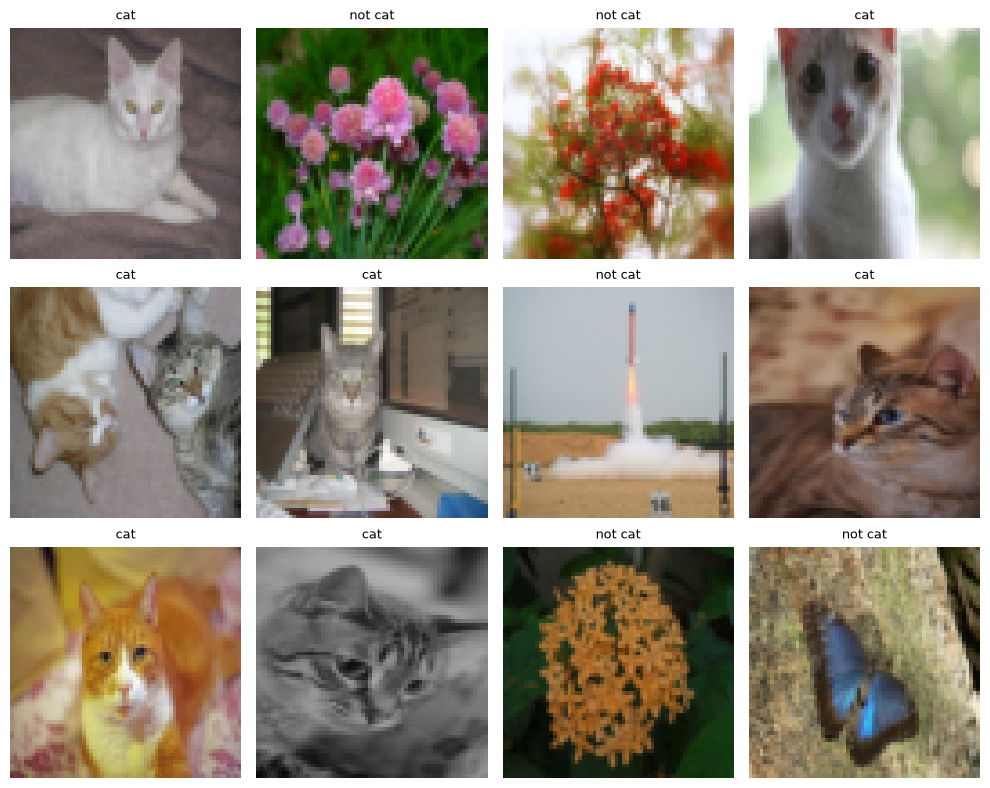

In [30]:
# Mostra 12 imagens aleatórias do dataset
n_images = 12
indices = np.random.default_rng(42).choice(len(X), size=n_images, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for ax, i in zip(axes.ravel(), indices):
    img = X[i].reshape(64, 64, 3).astype("uint8")
    label = "cat" if y[i] == 1 else "not cat"

    ax.imshow(img)
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. Separe os dados em treino e teste
Agora que você já tem o dataset carregado em `X` e `y`, o próximo passo é separar em:
- **treino:** dados usados para o modelo aprender;
- **teste:** dados usados para verificar se o modelo generaliza.

Utilize `random_state=42` para tornar a divisão reproduzível e preserve a proporção das classes nos dois conjuntos.

### Responda
1. Qual proporção você escolheu e por que?
2. Qual é o sentido de separar os dados em treino e teste?
3. Por que não devemos avaliar o modelo somente nos dados usados no treinamento?

> Nesta atividade introdutória, utilizaremos o conjunto de teste para uma comparação simples. Em projetos reais, normalmente mantemos um conjunto de validação para escolher configurações e reservamos o teste para a avaliação final.

## 3. Prepare os dados

Antes de treinar o modelo, investigue como os valores dos pixels estão representados no dataset.

Verifique o menor e o maior valor encontrado e pesquise se é necessário realizar alguma transformação nesses valores antes de fornecê-los à rede neural.

Depois, transforme os dados para o formato utilizado pelo PyTorch.

Verifique também qual deve ser o tipo (`dtype`) dos tensores de entrada e dos labels para utilizar a `BCEWithLogitsLoss`.

### Responda
1. Qual é o menor e o maior valor dos pixels?
2. Foi necessário normalizar os dados? Por quê?
3. Qual transformação você realizou?
4. Por que escolheu essa transformação?
5. O que é um tensor?

## 4. Organize os dados para o treinamento
Use o **DataLoader** do PyTorch para organizar os dados de treino.

Para o baseline, utilize **batch size = 32**.

### Responda
1. O que é um DataLoader?
2. O que é um batch?
3. O que significa batch size = 32?
4. Por que embaralhamos os dados de treino?

## 5. Crie a rede neural

Crie uma rede neural simples:

**entrada → camada com 16 neurônios → ReLU → uma saída (logit)**

Como este é um problema binário (gato ou não-gato), use um neurônio de saída. Não inclua a função `sigmoid` na arquitetura do modelo. A `BCEWithLogitsLoss` já realiza essa operação internamente durante o cálculo da loss.

### Responda
1. Quantos valores entram na rede para cada exemplo?
2. Quantos neurônios existem na camada intermediária?
3. Qual função de ativação você utilizou?
4. Quantas saídas sua rede possui?
5. Por que você escolheu essa função de ativação?

## 6. Configure o treinamento

- **Loss:** `BCEWithLogitsLoss`;
- **Optimizer:** Adam;
- **Learning rate:** 0.001;
- **Epochs:** 10.

**Baseline** é o modelo inicial que será usado como referência.

Como este problema é binário, usamos 1 saída (logit) e `BCEWithLogitsLoss`, que já combina sigmoid + binary cross-entropy com melhor estabilidade numérica.

Dica prática: garanta que `y` esteja em `float32` e com o mesmo formato da saída do modelo (por exemplo, `[batch, 1]`).

### Responda

1. O que é a loss?
2. Por que `BCEWithLogitsLoss` é adequada neste caso?
3. O que o optimizer faz?
4. O que é o learning rate?
5. O que é uma epoch?

## 7. Treine o baseline
Implemente o treinamento.

O modelo deverá:
1. receber os dados;
2. fazer uma previsão;
3. calcular o erro;
4. aprender a partir desse erro.

Registre a **loss de cada epoch**.

### Responda
1. A loss diminuiu durante o treinamento?
2. O que isso indica?
3. Qual foi a loss final?

## 8. Veja o resultado
Crie um gráfico da **loss ao longo das epochs** e calcule a **accuracy** nos dados de teste.

Como a saída do modelo é um logit, aplique `torch.sigmoid()` durante a avaliação para obter uma probabilidade. Considere valores maiores ou iguais a `0.5` como classe 1 e valores menores que `0.5` como classe 0.

### Registre
**Accuracy do baseline:**  
**Loss final do baseline:**  

### Responda
1. O que o gráfico da loss mostra?
2. Qual foi a accuracy?
3. O que significa, por exemplo, uma accuracy de 80%?

## 9. Faça uma alteração

Escolha uma única característica do treinamento ou da rede para alterar. Pesquise uma possibilidade e explique por que decidiu testá-la.

Se precisar de ideias, você pode investigar alterações na quantidade de neurônios, learning rate, batch size ou número de epochs.

Crie e treine um novo modelo desde o início, mantendo a mesma divisão dos dados utilizada no baseline. Altere somente uma característica. Não continue o treinamento do modelo anterior.

Antes de testar, responda:

1. O que você vai alterar?
2. Por que escolheu isso?
3. O que você acha que vai acontecer?

## 10. Compare
Compare seu experimento com o baseline.

| | Baseline | Meu experimento |
|---|---|---|
| O que mudou? | — | |
| Accuracy | | |
| Loss final | | |

### Responda
1. O que você mudou?
2. A accuracy aumentou ou diminuiu?
3. A loss mudou?
4. O que você observou?